In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import quaia
from astropy.coordinates import SkyCoord

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

In [3]:
cmap_map = 'plasma'

# Load data from local machine

In [4]:
fn_gcatlo = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock1.fits'
fn_gcathi = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20.5/mock_catalog_quaia_G20.5_mock1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
name_catalog = '$Gaia$-$unWISE$ Quasar Mock Catalog'
abbrv_catalog = 'Quaia'

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
# for plotting purposes
fac_stdev = 0.5 # 1.45 # 1.5

## Quasar mock catalog

In [10]:
tab_gcatlo = Table.read(fn_gcatlo)
N_gcatlo = len(tab_gcatlo)
print(f"Number of data sources: {N_gcatlo}")

Number of data sources: 755512


In [11]:
print(tab_gcatlo.meta)

OrderedDict()


In [12]:
print(f"Column names: {tab_gcatlo.columns}")

Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


In [13]:
tab_gcathi = Table.read(fn_gcathi)
N_gcathi = len(tab_gcathi)
print(f"Number of data sources: {N_gcathi}")

Number of data sources: 1295221


### Make map of quasar number counts

In [14]:
# mask the plane
mask = 20 #20 #30
c_gcatlo = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree)
mask_gcatlo = np.abs(c_gcatlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcatlo_mask = len(tab_gcatlo['ra'][mask_gcatlo])

In [15]:
pixel_indices_gcatlo_mask = hp.ang2pix(NSIDE, tab_gcatlo['ra'][mask_gcatlo], tab_gcatlo['dec'][mask_gcatlo], lonlat=True)
map_gcatlo = np.bincount(pixel_indices_gcatlo_mask, minlength=NPIX)

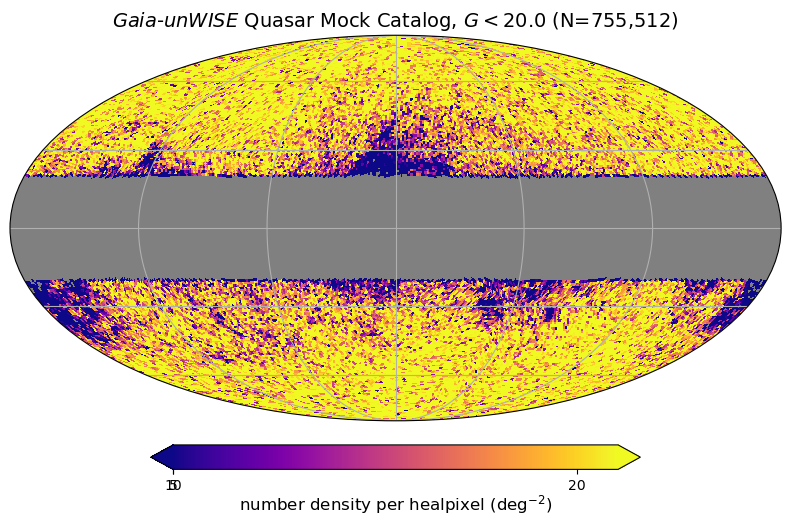

In [16]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_gcatlo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.median(map_gcatlo)+fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [17]:
c_gcathi = SkyCoord(ra=tab_gcathi['ra']*u.degree, dec=tab_gcathi['dec']*u.degree)
mask_gcathi = np.abs(c_gcathi.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcathi_mask = len(tab_gcathi['ra'][mask_gcathi])

In [18]:
pixel_indices_gcathi_mask = hp.ang2pix(NSIDE, tab_gcathi['ra'][mask_gcathi], tab_gcathi['dec'][mask_gcathi], lonlat=True)
map_gcathi = np.bincount(pixel_indices_gcathi_mask, minlength=NPIX)

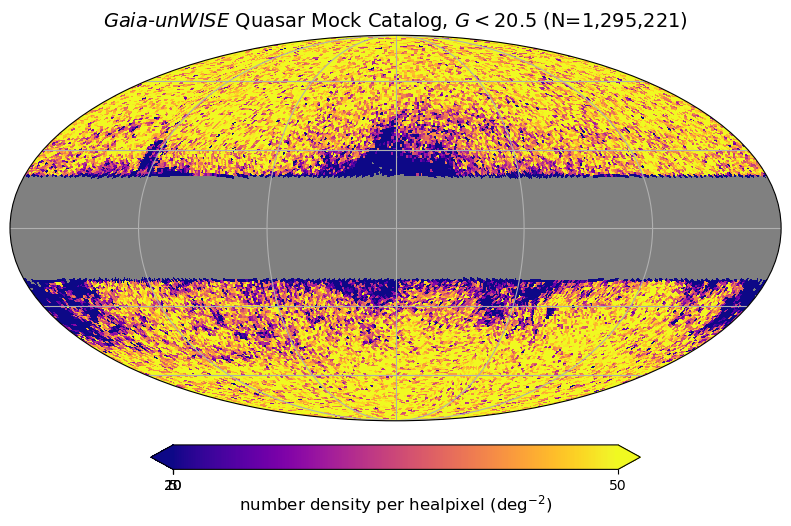

In [19]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_gcathi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi)-fac_stdev*np.std(map_gcathi), max=np.median(map_gcathi)+fac_stdev*np.std(map_gcathi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 50])

## Random catalog

In [20]:
tab_randlo = Table.read(fn_randlo)
N_randlo = len(tab_randlo)
print(f"Number of random sources: {N_randlo}")

Number of random sources: 7563151


In [21]:
print(f"Column names: {tab_randlo.columns}")

Column names: <TableColumns names=('ra','dec','ebv')>


In [22]:
tab_randhi = Table.read(fn_randhi)
N_randhi = len(tab_randhi)
print(f"Number of random sources: {N_randhi}")

Number of random sources: 12955802


### Make maps of random number counts

In [23]:
c_randlo = SkyCoord(ra=tab_randlo['ra'], dec=tab_randlo['dec'])
mask_randlo = np.abs(c_randlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_randlo_mask = len(tab_randlo['ra'][mask_randlo])

In [24]:
pixel_indices_randlo_mask = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo], tab_randlo['dec'][mask_randlo], lonlat=True)
map_randlo = np.bincount(pixel_indices_randlo_mask, minlength=NPIX)

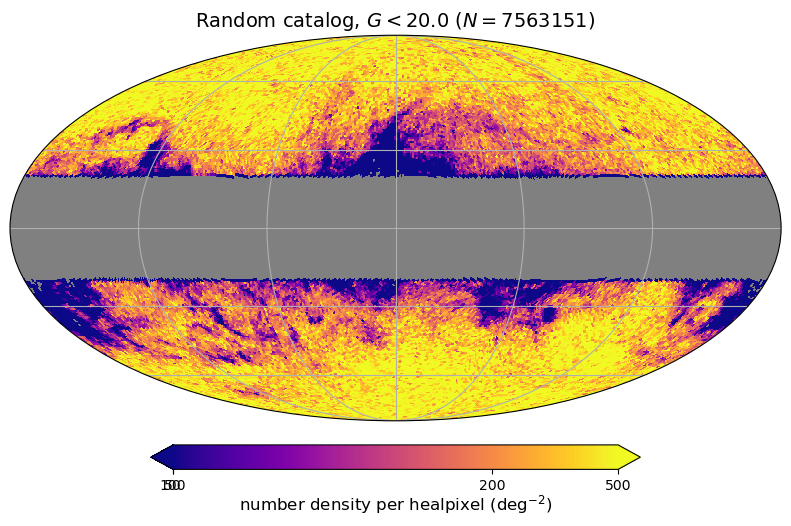

In [25]:
projview(map_randlo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randlo)-fac_stdev*np.std(map_randlo), 
            max=np.median(map_randlo)+fac_stdev*np.std(map_randlo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 100, 200, 500]) 

In [26]:
c_randhi = SkyCoord(ra=tab_randhi['ra'], dec=tab_randhi['dec'])
mask_randhi = np.abs(c_randhi.galactic.b.value)>=mask # use galactic coordinates from data 
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])

In [27]:
pixel_indices_randhi_mask = hp.ang2pix(NSIDE, tab_randhi['ra'][mask_randhi], tab_randhi['dec'][mask_randhi], lonlat=True)
map_randhi = np.bincount(pixel_indices_randhi_mask, minlength=NPIX)

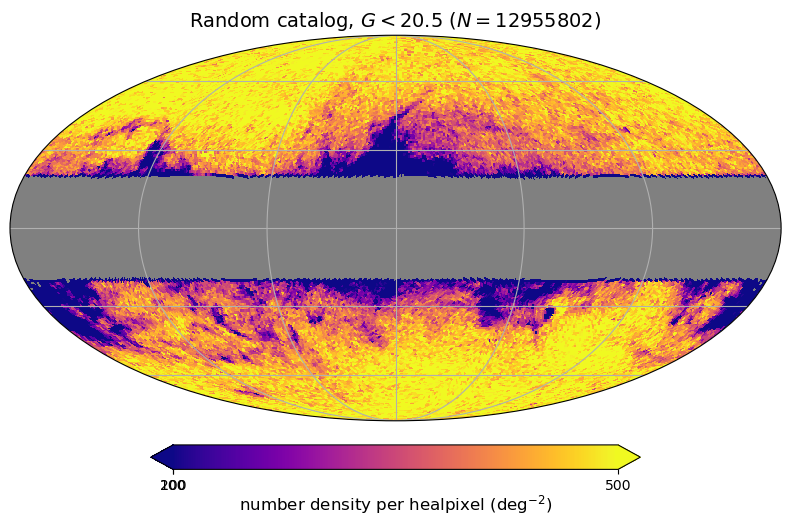

In [28]:
projview(map_randhi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randhi)-fac_stdev*np.std(map_randhi), max=np.median(map_randhi)+fac_stdev*np.std(map_randhi), 
            norm='log', graticule=True,
            cbar_ticks=[100, 200, 500]) 

## Remove the selection function
### Start with mock catalogs

In [29]:
selfunc_lo = hp.fitsfunc.read_map(fn_sello)

In [30]:
map_selfunc_lo = map_gcatlo/selfunc_lo

/tmp/ipykernel_28428/515644528.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


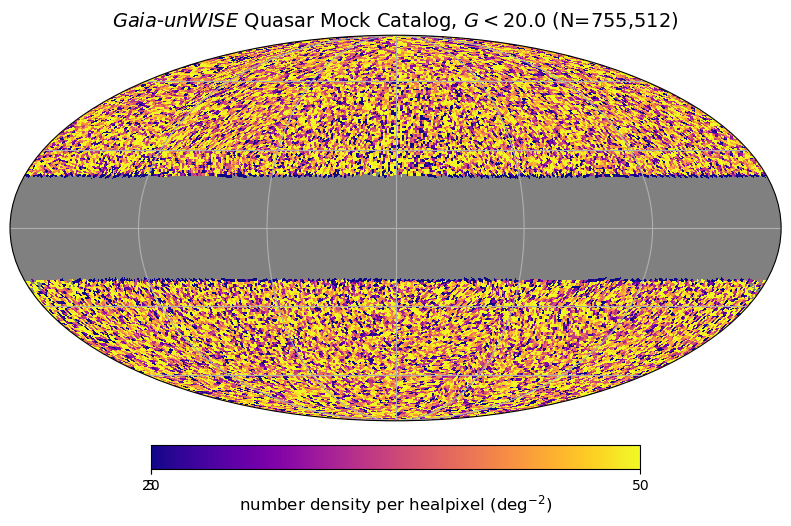

In [31]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_selfunc_lo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_lo)-fac_stdev*np.nanstd(map_selfunc_lo), max=np.nanmedian(map_selfunc_lo)+fac_stdev*np.nanstd(map_selfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 20, 50]) 

In [32]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [33]:
map_selfunc_hi = map_gcathi/selfunc_hi

/tmp/ipykernel_28428/189966545.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_hi = map_gcathi/selfunc_hi


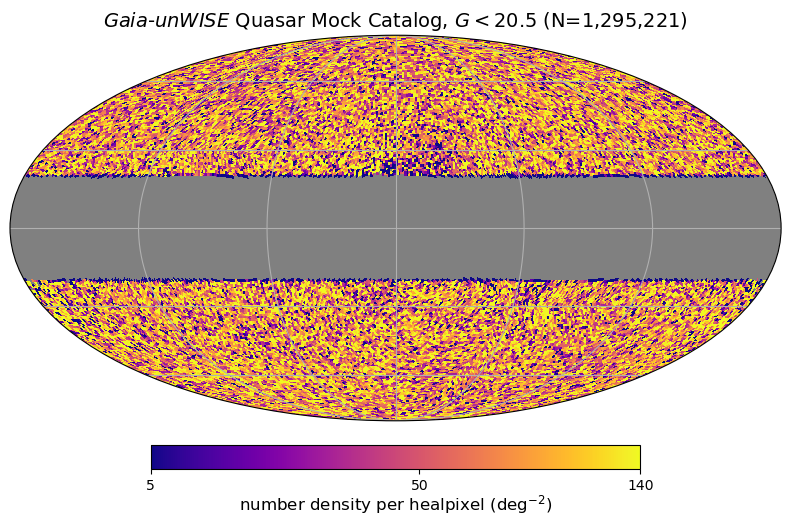

In [34]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_selfunc_hi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_hi)-fac_stdev*np.nanstd(map_selfunc_hi), max=np.nanmedian(map_selfunc_hi)+fac_stdev*np.nanstd(map_selfunc_hi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 50, 140]) 

### Now random catalog

In [35]:
map_randselfunc_lo = map_randlo/selfunc_lo

/tmp/ipykernel_28428/1639919514.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_lo = map_randlo/selfunc_lo


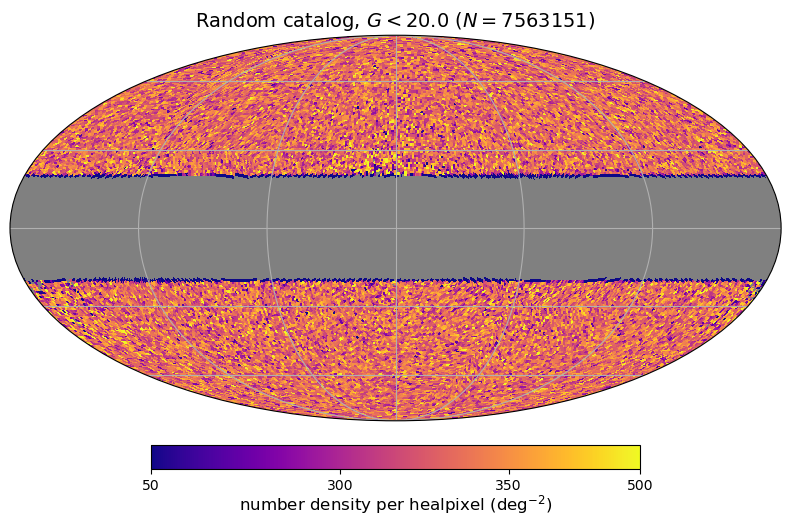

In [36]:
projview(map_randselfunc_lo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_randselfunc_lo)-fac_stdev*np.nanstd(map_randselfunc_lo), 
            max=np.nanmedian(map_randselfunc_lo)+fac_stdev*np.nanstd(map_randselfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 300, 350, 500]) 

In [37]:
map_randselfunc_hi = map_randhi/selfunc_hi

/tmp/ipykernel_28428/231715387.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_hi = map_randhi/selfunc_hi


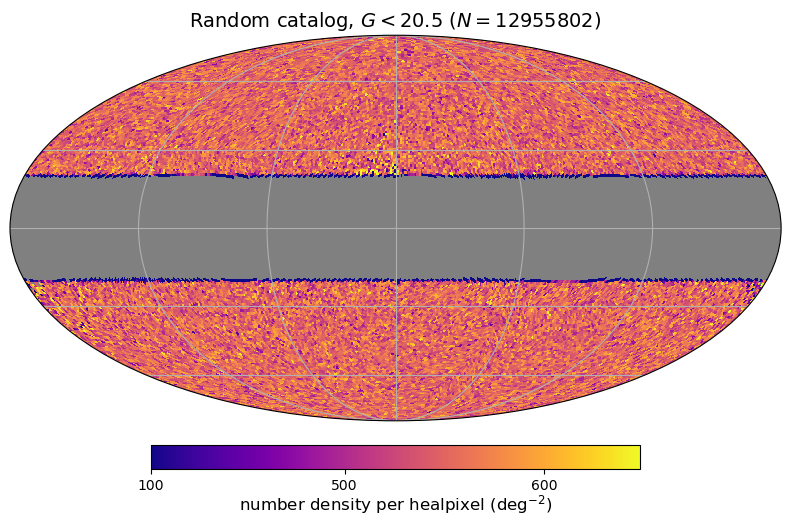

In [38]:
projview(map_randselfunc_hi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
         unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_randselfunc_hi)-fac_stdev*np.nanstd(map_randselfunc_hi), 
         max=np.nanmedian(map_randselfunc_hi)+fac_stdev*np.nanstd(map_randselfunc_hi), norm='log', graticule=True, 
         cbar_ticks=[100, 500, 600]) 

# Plot the $n(z)$ distribution

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


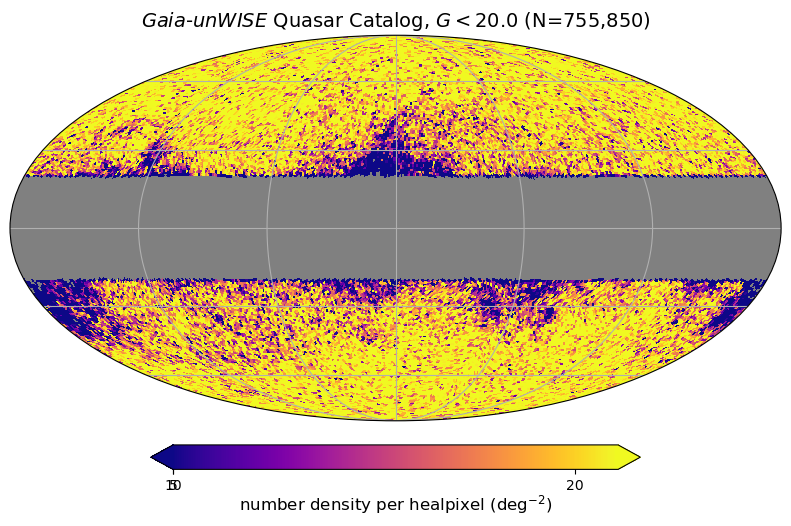

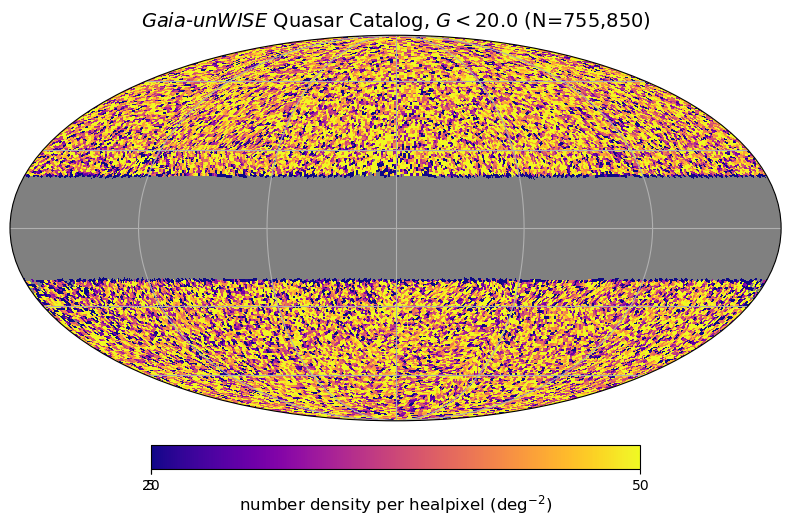

In [39]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, 
                                                                               fn_sello, mask = mask, plot = True, fac_stdev = fac_stdev)

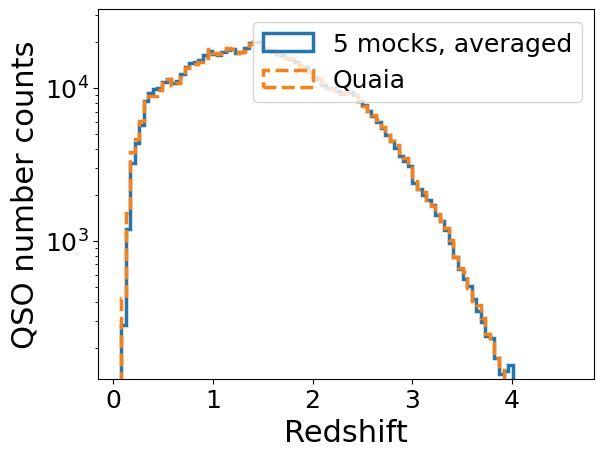

In [40]:
mean = []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,6):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i = Table.read(fn_gcatlo_i)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
plt.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', label = '5 mocks, averaged', linewidth = 2.5)
plt.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, linestyle = '--', linewidth = 2.5)
plt.xlabel('Redshift')
plt.ylabel('QSO number counts')
plt.yscale('log')
plt.ylim(125,)
plt.legend()
plt.show()

## See the impact of masking

In [41]:
mean, mean_mask = [], []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,6):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, G_lo, 
                                                                                           fn_sello, mask = mask)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
    # try it wth the mask
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'][mask_gcatlo_i], bins = bins)
    mean_mask.append(hist)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


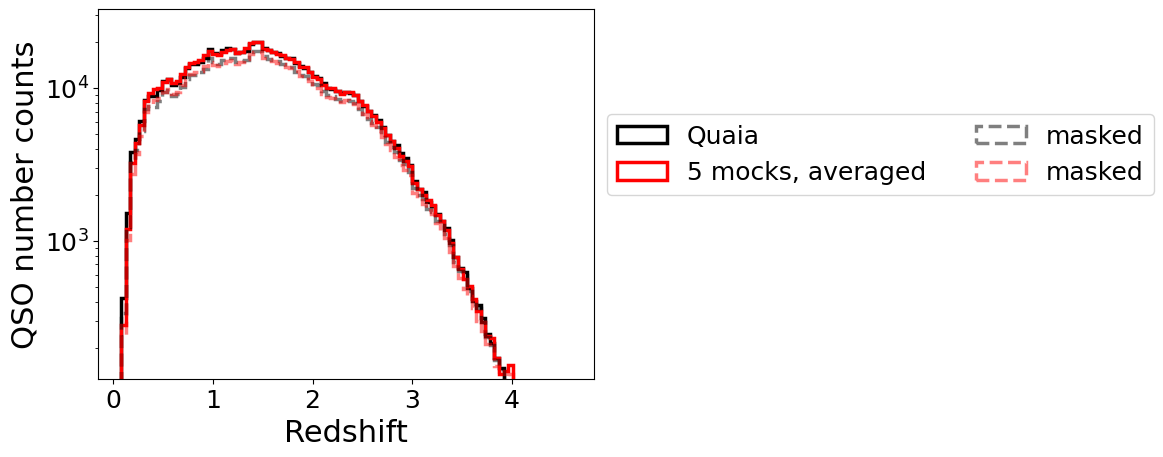

In [42]:
n_data, bins_data, patches_data = plt.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, linewidth = 2.5, 
                                           color = 'black')
n_mock, bins_mock, patches_mock = plt.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', label = '5 mocks, averaged', 
                                         linewidth = 2.5, color = 'red')
n_data_mask, bins_data_mask, patches_data_mask = plt.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', label = 'masked', 
                                                          bins = bins, linewidth = 2.5, linestyle = '--', color = 'black', alpha = 0.5)
n_mock_mask, bins_mock_mask, patches_mock_mask = plt.hist(bins[:-1], bins, weights = np.mean(mean_mask, axis = 0), histtype = 'step', 
                                                          label = 'masked', linewidth = 2.5, color = 'red', linestyle = '--', 
                                                          alpha = 0.5)
plt.xlabel('Redshift')
plt.ylabel('QSO number counts')
plt.yscale('log')
plt.ylim(125,)
plt.legend(ncol = 2, bbox_to_anchor=(1, 0.25, 0.5, 0.5))
plt.show()

/tmp/ipykernel_28428/2494672642.py:2: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(quaia.recenter(bins_data), n_mock_mask/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')


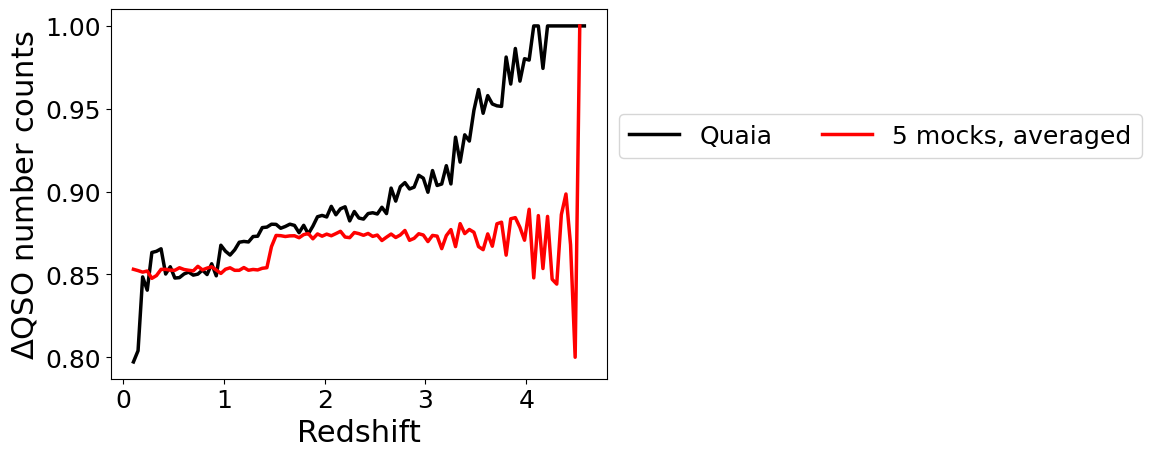

In [43]:
plt.plot(quaia.recenter(bins_data), n_data_mask/n_data, label = 'Quaia', linewidth = 2.5, color = 'black')
plt.plot(quaia.recenter(bins_data), n_mock_mask/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')
plt.xlabel('Redshift')
plt.ylabel('$\Delta$QSO number counts')
plt.legend(ncol = 2, bbox_to_anchor=(1, 0.25, 0.5, 0.5))
plt.show()

# Compute the projected angular auto-power spectrum
## First convert redshift space to X, Y, Z coordinates

In [44]:
correction = -5205.182232081812

In [45]:
c = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree, distance=quaia.comoving_dist(tab_gcatlo['redshift_quaia']))
X1, Y1, Z1 = c.cartesian.xyz.value-correction

## Now measure the pair counts

In [46]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 150.0 # 20.0 #50.0
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

In [47]:
nthreads = 18

In [48]:
# refer to https://en.wikipedia.org/wiki/Hubble%27s_law#Dimensionless_Hubble_constant
DD_counts, api_time = theory.DD(autocorr = 1, nthreads = nthreads, binfile = rbins, periodic = False,
                                X1 = X1[mask_gcatlo], Y1 = Y1[mask_gcatlo], Z1 = Z1[mask_gcatlo], weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], 
                                weight_type='pair_product', 
                                output_ravg = True, c_api_timer = True) # cz/H0 = Mpc/h = m/s * km/1000 m / (100 km/s/Mpc h)
api_time

0.6612480000000001

### Generate a $z$ distribution for the random catalog
#### Try interpolating the cdf so it's more smooth

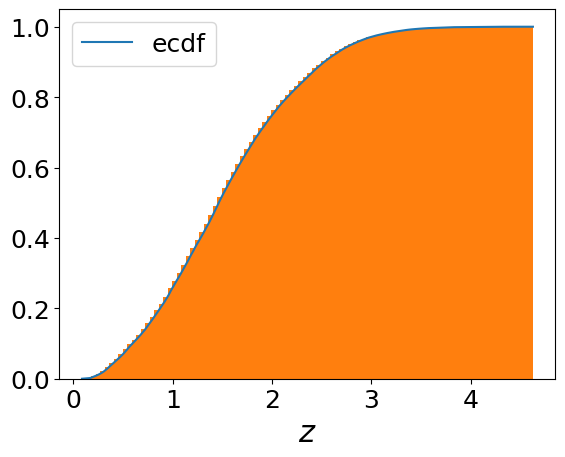

In [49]:
quaia.z_dist(tab_datalo, tab_randlo, mask_datalo, mask_randlo, N_datalo_mask, N_randlo_mask, plot = True, mask = mask)

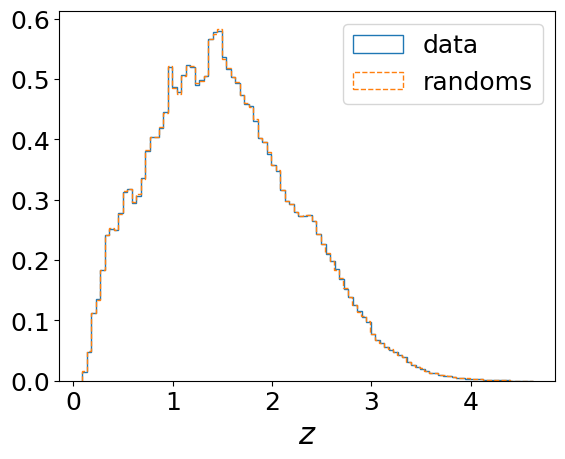

In [50]:
plt.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', density = True, label = 'data', bins = 100)
plt.hist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo], histtype = 'step', density = True, label = 'randoms', bins = 100, linestyle = '--')
plt.xlabel('$z$')
plt.legend()
plt.show()

In [51]:
c = SkyCoord(ra=tab_randlo['ra'][mask_randlo], dec=tab_randlo['dec'][mask_randlo], 
             distance=quaia.comoving_dist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo]))
X2, Y2, Z2 = c.cartesian.xyz.value-correction

### Now measure clustering in random catalog

In [52]:
DR_counts, api_time = theory.DD(autocorr = 0, nthreads = nthreads, binfile = rbins, periodic = False,
                                X1 = X1[mask_gcatlo], Y1 = Y1[mask_gcatlo], Z1 = Z1[mask_gcatlo], weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], 
                                X2 = X2, Y2 = Y2, Z2 = Z2,
                                weights2 = 1/selfunc_lo[pixel_indices_randlo_mask], weight_type='pair_product', output_ravg = True, 
                                c_api_timer = True)
api_time

2.627089

In [53]:
RR_counts, api_time = theory.DD(autocorr = 1, nthreads = nthreads, binfile = rbins, periodic = False,
                                X1 = X2, Y1 = Y2, Z1 = Z2, weights1 = 1/selfunc_lo[pixel_indices_randlo_mask], 
                                weight_type='pair_product',
                                output_ravg = True, c_api_timer = True)
api_time

5.311197

### Plot for sanity check

In [54]:
DD_counts['npairs'] = DD_counts['npairs']*DD_counts['weightavg']
DR_counts['npairs'] = DR_counts['npairs']*DR_counts['weightavg']
RR_counts['npairs'] = RR_counts['npairs']*RR_counts['weightavg']

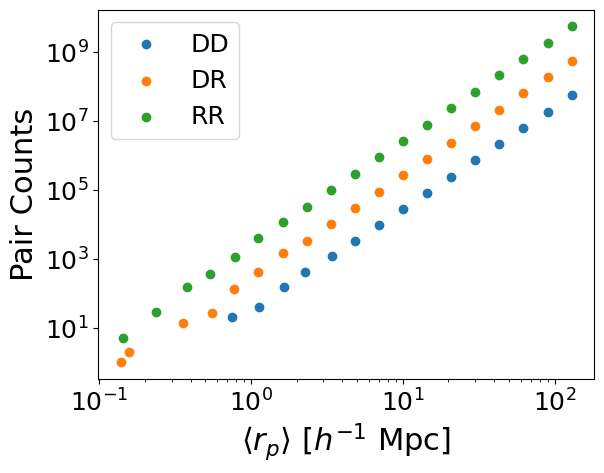

In [55]:
plt.scatter(DD_counts['ravg'], DD_counts['npairs'], label = 'DD')
plt.scatter(DR_counts['ravg'], DR_counts['npairs'], label = 'DR')
plt.scatter(RR_counts['ravg'], RR_counts['npairs'], label = 'RR')
plt.xlabel(r'$\langle r_{p}\rangle$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("Pair Counts")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Now convert the 2-D Pair counts into a $xi(r)$


In [56]:
# All the pair counts are done, get the angular correlation function
cf = convert_3d_counts_to_cf(N_gcatlo_mask, N_gcatlo_mask, N_randlo_mask, N_randlo_mask,
                                DD_counts, DR_counts,
                                DR_counts, RR_counts)

/tmp/ipykernel_28428/3786833045.py:7: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-3, 10)


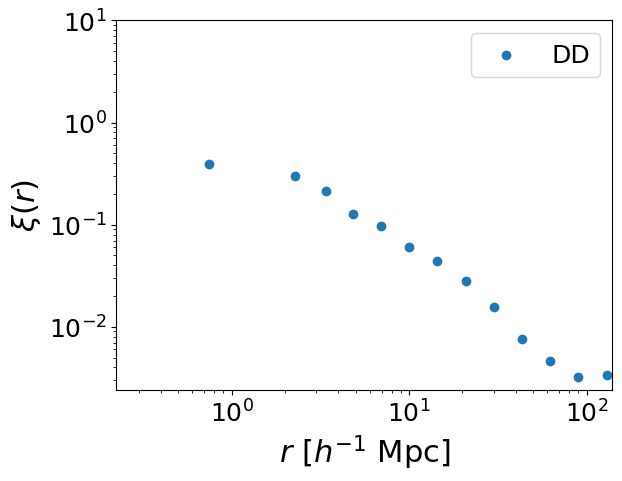

In [57]:
plt.scatter(DD_counts['ravg'], cf, label = 'DD')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylim(-3, 10)
plt.xlim(rmin+0.125, rmax-10)
plt.show()

### Compare to data

In [58]:
cf_mock, ravg_mock = quaia.xi_r(tab_gcatlo[mask_gcatlo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask, pixel_indices_randlo_mask, 
                                N_gcatlo_mask, N_randlo_mask, RR_counts, correction, rbins = rbins, mask = mask, nthreads = nthreads)

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:304: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
  if RR_counts == None:


In [59]:
cf_data, ravg_data = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, pixel_indices_randlo_mask, 
                                N_datalo_mask, N_randlo_mask, RR_counts, correction, rbins = rbins, mask = mask, nthreads = nthreads)

In [60]:
cf_data_test, ravg_data_test = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, 
                                          pixel_indices_randlo_mask, N_datalo_mask, N_randlo_mask, None, correction, rbins = rbins, mask = mask, nthreads = nthreads)

/tmp/ipykernel_28428/2362526287.py:8: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-1,)


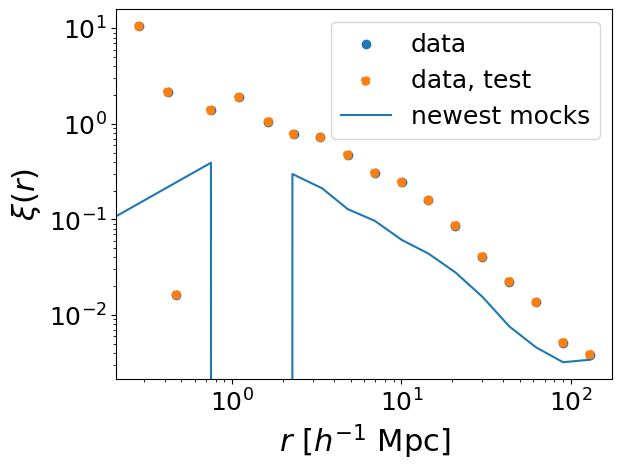

In [61]:
plt.scatter(ravg_data, cf_data, label = 'data')
plt.scatter(ravg_data_test, cf_data_test, label = 'data, test', linestyle = '--')
plt.plot(ravg_mock, cf_mock, label = 'newest mocks')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.ylim(-1,)
plt.legend()
plt.show()

### Average the mocks

In [62]:
cf_mocks, ravg_mocks = [], []
for i in range(1,31):
    
    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, G_lo, 
                                                                                           fn_sello, mask = mask)
    cf_mock_i, ravg_mock_i = quaia.xi_r(tab_gcatlo_i[mask_gcatlo_i], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask_i, 
                                    pixel_indices_randlo_mask, N_gcatlo_mask_i, N_randlo_mask, RR_counts, correction, rbins = rbins, mask = mask, nthreads = nthreads)
    cf_mocks.append(cf_mock_i)
    ravg_mocks.append(ravg_mock_i)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra

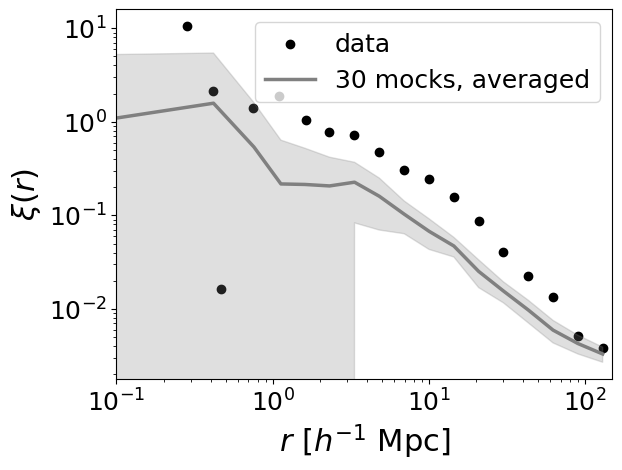

In [63]:
cf_mocks_mean = np.mean(cf_mocks, axis = 0)
ravg_mocks_mean = np.mean(ravg_mocks, axis = 0)
yerr = np.std(cf_mocks, axis = 0)

plt.scatter(ravg_data, cf_data, label = 'data', color = 'black')
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '30 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)

plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

### Compare to https://arxiv.org/abs/2506.05612
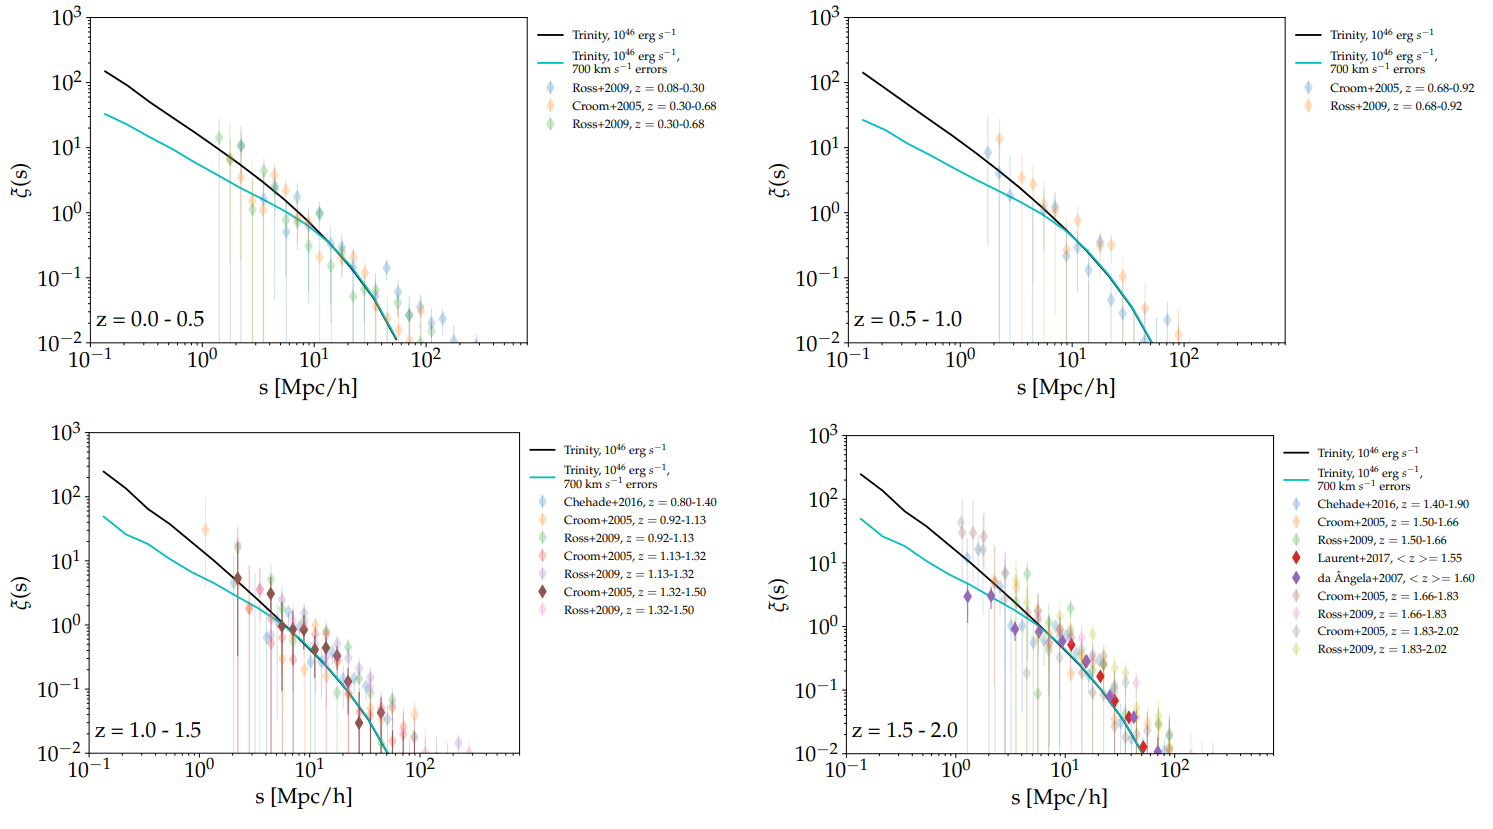

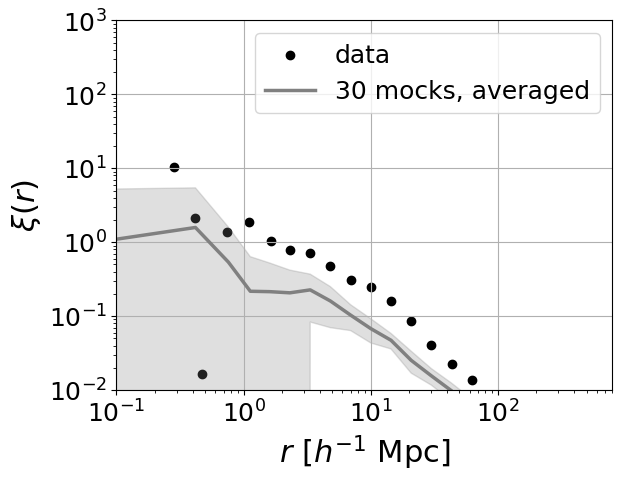

In [64]:
cf_mocks_mean = np.mean(cf_mocks, axis = 0)
yerr = np.std(cf_mocks, axis = 0)

plt.scatter(ravg_data, cf_data, label = 'data', color = 'black')
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '30 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)

plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-1, 8e2)
plt.ylim(1e-2, 1e3)
plt.legend()
plt.grid()
plt.show()

## Check impact of masking

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


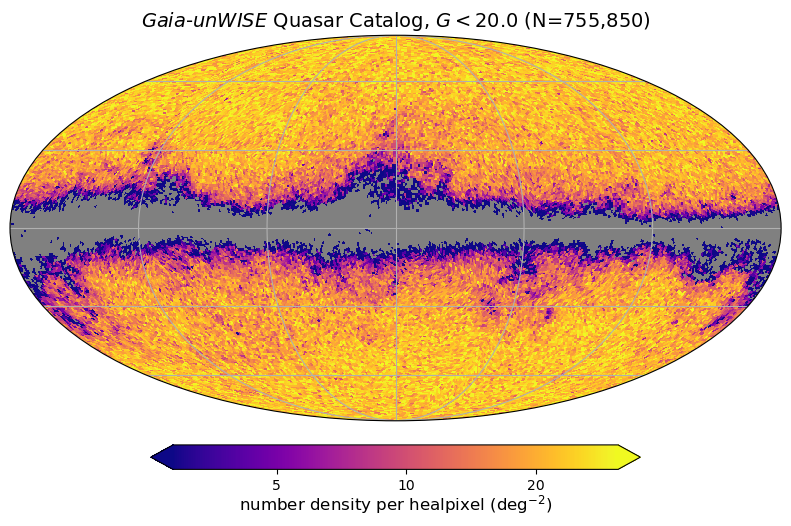

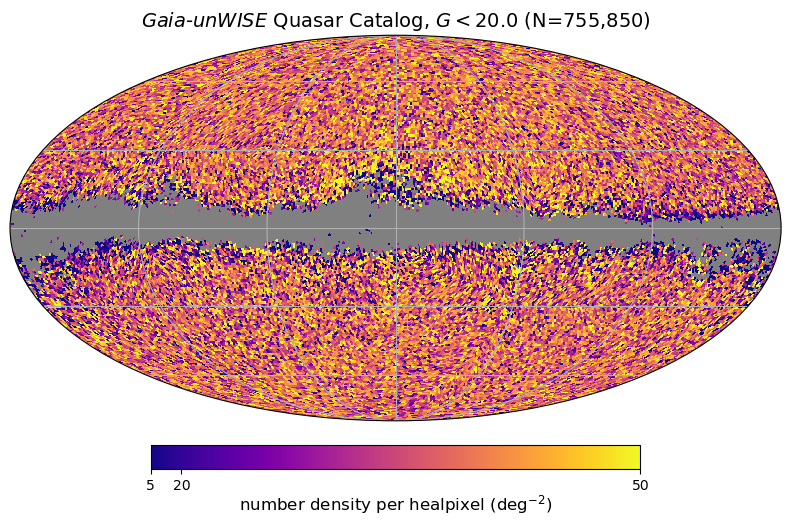

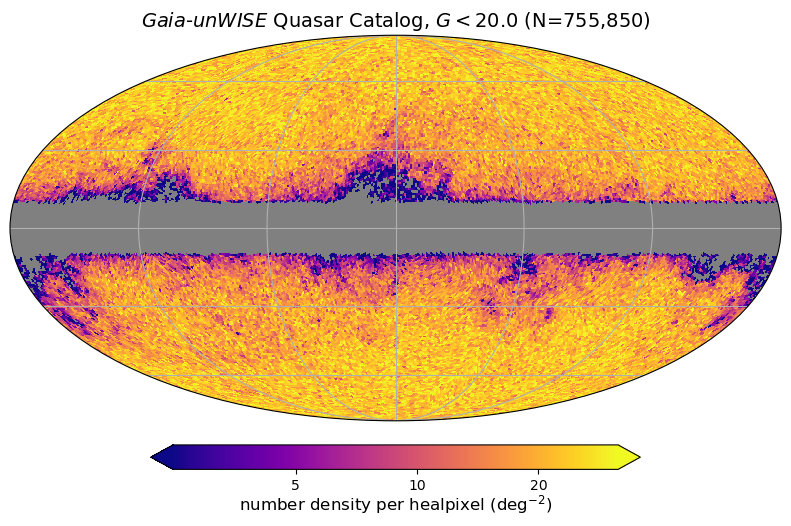

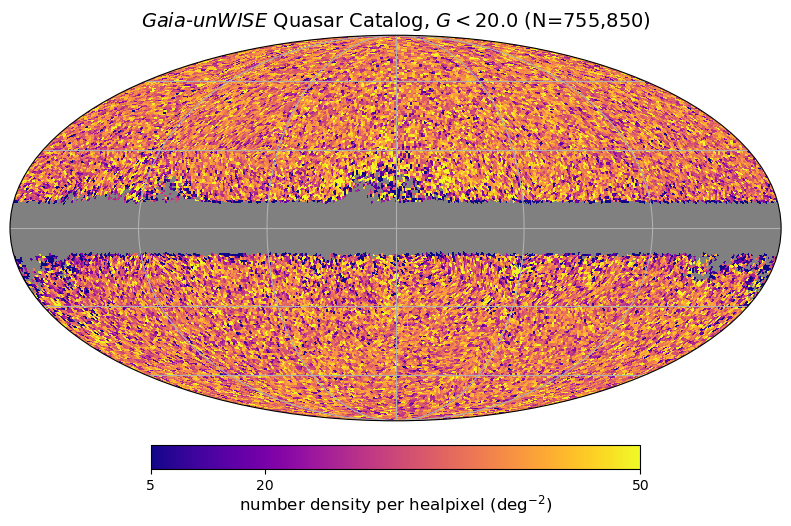

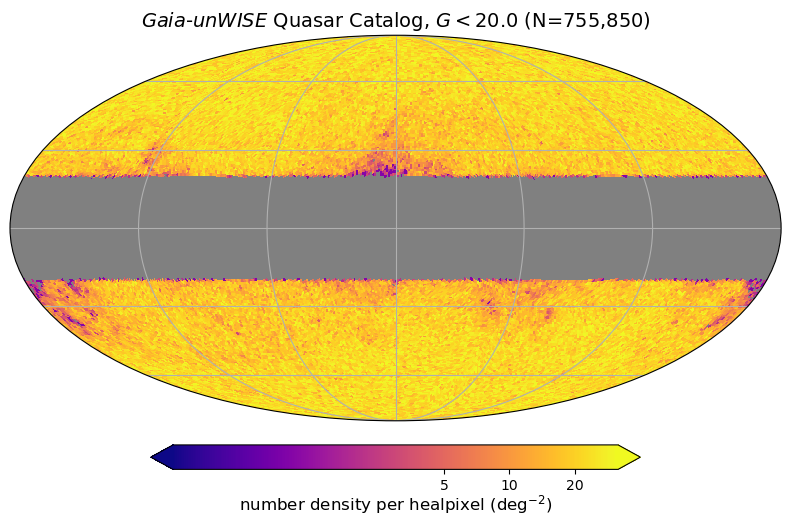

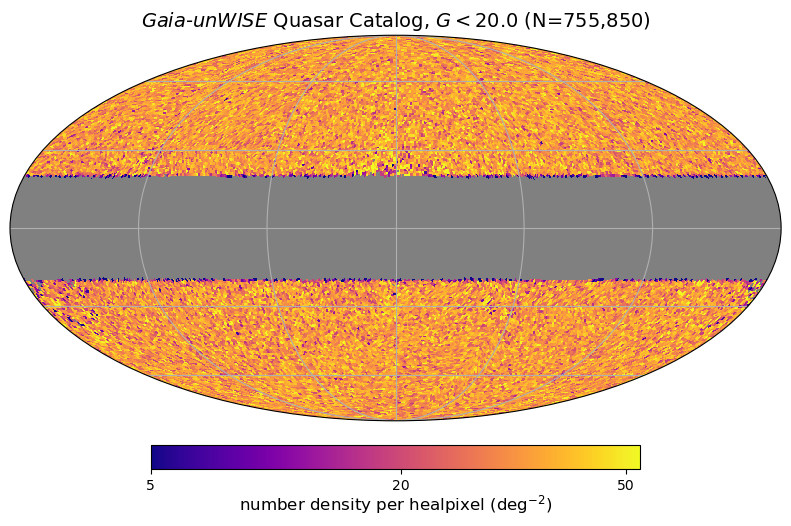

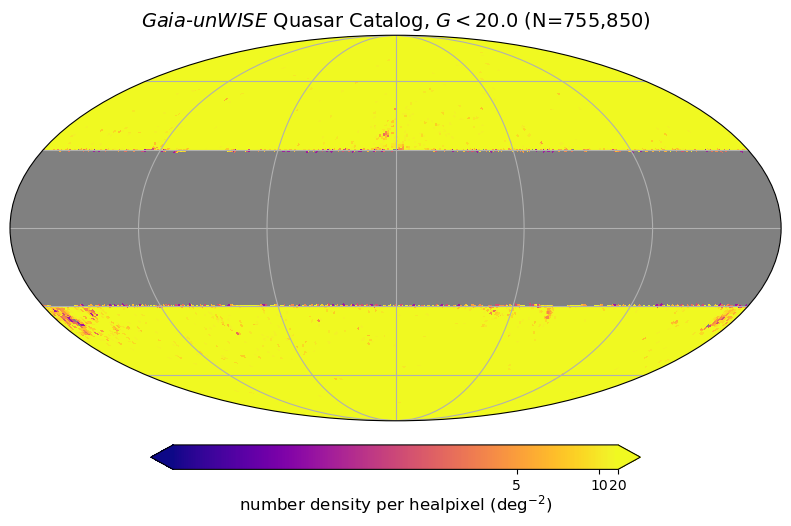

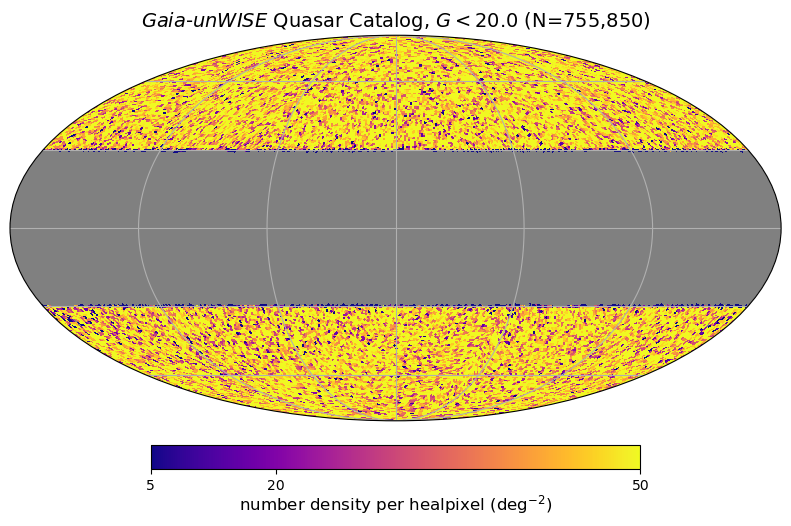

In [65]:
cf_data_b_array, ravg_data_b_array  = [], []
b_array = [0, 10, 20, 30]
fac_stdev_array = [1.5, 1.5, 1.45, 0.5] #1.45, 0.5
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, 
                                                                mask = b_array[i], plot = True, fac_stdev = fac_stdev_array[i])

    mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, mask = b_array[i])
    
    pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    cf_data_b, ravg_data_b = quaia.xi_r(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], selfunc_lo, pixel_indices_datalo_b, 
                                        pixel_indices_randlo_b, N_datalo_b, N_randlo_b, None, correction, rbins = rbins, mask = b_array[i], nthreads = nthreads)
    cf_data_b_array.append(cf_data_b)
    ravg_data_b_array.append(ravg_data_b)

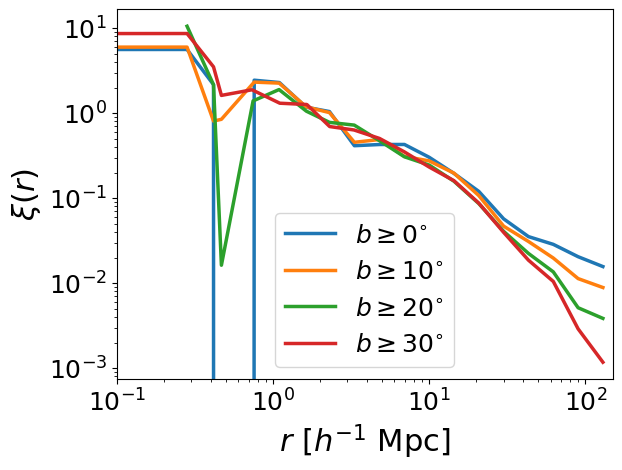

In [66]:
for i in range(len(b_array)):
    plt.plot(ravg_data_b_array[i], cf_data_b_array[i], label = '$b\geq{:d}^{{\circ}}$'.format(b_array[i]),linewidth = 2.5)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

# Questions
- why are npairs higher for lower pimax?
- negative wp? due to DR? bad? --> no sometimes clustering is negative (voids)
- why do they use hubble distance if z is not << 1?
- does wp still get rid of RSDs if we are integrating to pimax and not infinity?
- why does xi_r calculation change every time i run it? --> because of regenerating z's! should it fluctuate that much?
- is it ok that cartesian coordinates go from -x/2 to x/2? --> no?